In [4]:
# -----------------------------------------------
# Step 1: Import Libraries
# -----------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import plotly.graph_objects as go

# Optional: ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

c:\Users\ziya1\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


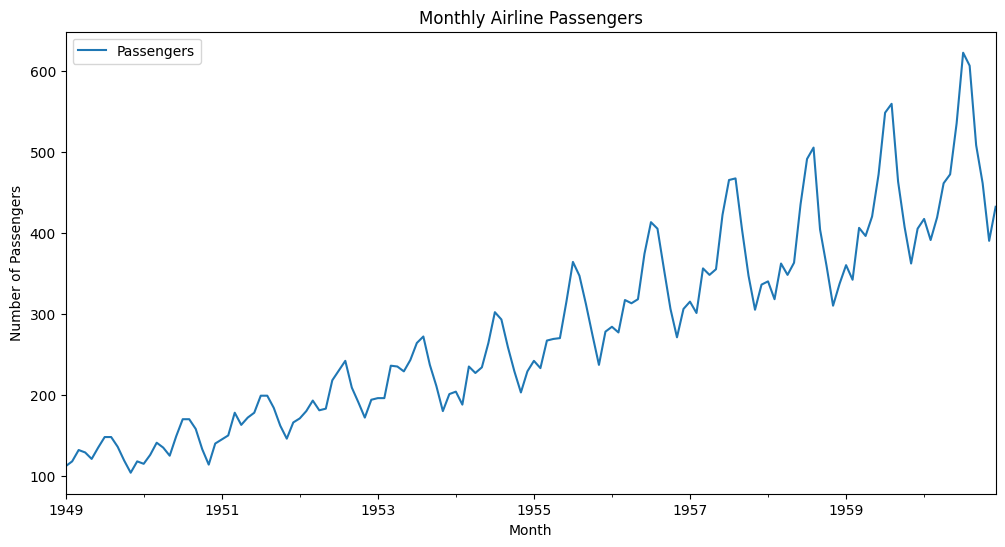

In [5]:
# -----------------------------------------------
# Step 2: Load Dataset
# -----------------------------------------------
# We'll use the classic Air Passengers dataset (monthly)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data.columns = ['Passengers']

# Quick look
print(data.head())
print(data.describe())

# Plot the raw data
data.plot(figsize=(12,6), title="Monthly Airline Passengers")
plt.ylabel("Number of Passengers")
plt.show()

In [6]:
# -----------------------------------------------
# Step 3: Preprocessing
# -----------------------------------------------
# Check for missing values
print(data.isnull().sum())

# Resample monthly (already monthly, but good habit)
data = data.resample('M').mean()

Passengers    0
dtype: int64


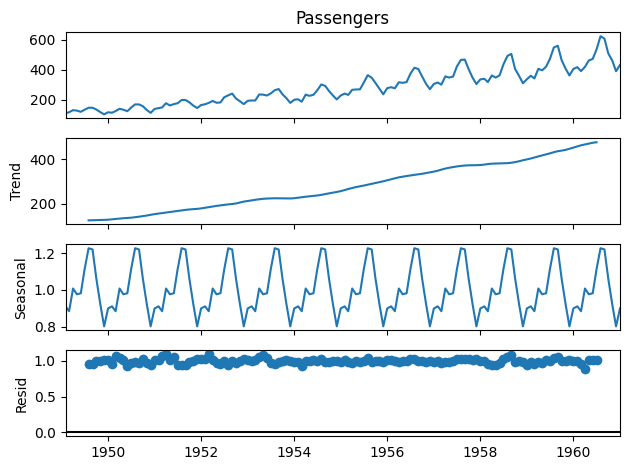

In [7]:
# -----------------------------------------------
# Step 4: Time Series Decomposition
# -----------------------------------------------
result = seasonal_decompose(data['Passengers'], model='multiplicative')
result.plot()
plt.show()

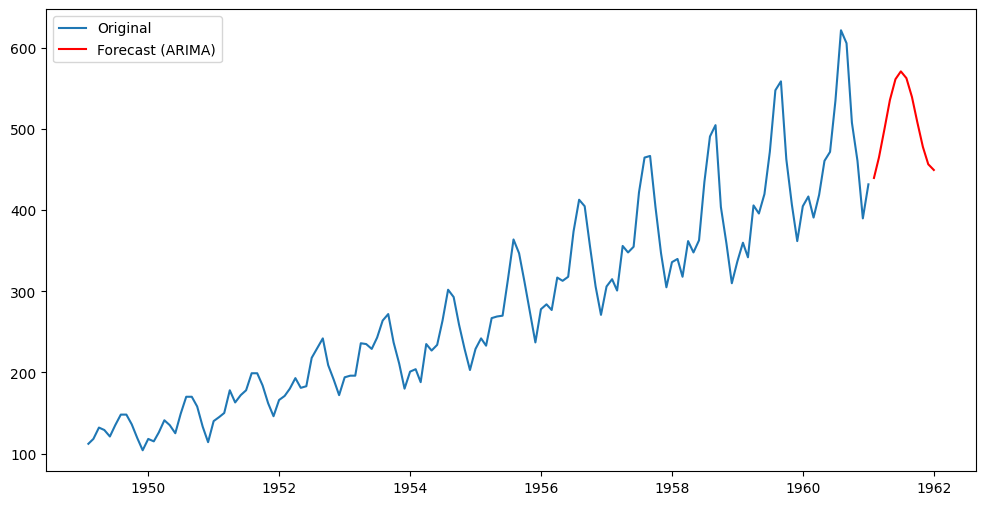

In [8]:
# -----------------------------------------------
# Step 5: Forecasting with ARIMA
# -----------------------------------------------
# Simple ARIMA model
model = ARIMA(data['Passengers'], order=(2,1,2))  # (p,d,q)
model_fit = model.fit()
forecast_arima = model_fit.forecast(steps=12)

# Plot ARIMA forecast
plt.figure(figsize=(12,6))
plt.plot(data, label='Original')
plt.plot(forecast_arima, label='Forecast (ARIMA)', color='red')
plt.legend()
plt.show()

16:51:26 - cmdstanpy - INFO - Chain [1] start processing
16:51:28 - cmdstanpy - INFO - Chain [1] done processing


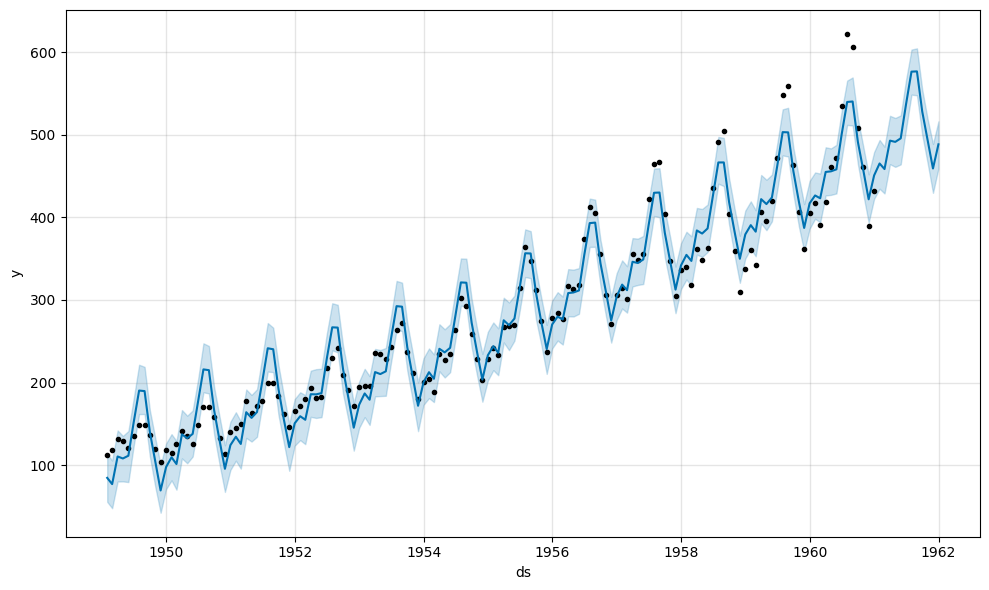

In [9]:
# -----------------------------------------------
# Step 6: Forecasting with Prophet
# -----------------------------------------------
# Prophet requires columns: ds (date), y (value)
df = data.reset_index().rename(columns={'Month':'ds','Passengers':'y'})

model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(df)

# Make future dataframe for 12 months ahead
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Plot Prophet forecast
model.plot(forecast)
plt.show()

In [17]:
# -----------------------------------------------
# Step 7: Interactive Visualization with Plotly
# -----------------------------------------------
fig = go.Figure()

# Original data
fig.add_trace(go.Scatter(x=data.index, y=data['Passengers'], name='Original'))

# Trend and Seasonality from decomposition
fig.add_trace(go.Scatter(x=result.trend.index, y=result.trend, name='Trend'))
fig.add_trace(go.Scatter(x=result.seasonal.index, y=result.seasonal, name='Seasonality'))

# ARIMA Forecast
forecast_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthBegin(),
                               periods=12, freq='M')
fig.add_trace(go.Scatter(x=forecast_index, y=forecast_arima, name='ARIMA Forecast'))

fig.update_layout(title="Airline Passengers Time Series Analysis",
                  xaxis_title="Date",
                  yaxis_title="Passengers",
                  legend=dict(x=0, y=1))


fig.write_html("airline_passengers.html")

In [18]:
import webbrowser
webbrowser.open("airline_passengers.html")

True